# Variability is the enemy: same average, wildly different delay

Two services have the *same* average processing time (say 1 second per request) and run at the
*same* utilization. An engineer expects the same latency. **They can differ by more than 10x.** The
hidden variable is the **variability** of the service time, measured by the squared coefficient of
variation `C² = Var(S) / E[S]²`.

The Pollaczek–Khinchine formula for the M/G/1 queue makes it precise — the mean waiting time is

`E[W] = ρ / (1-ρ) · E[S] · (1 + C²) / 2`

so the wait grows **linearly with C²**. Cutting service-time variance is often cheaper and more
effective than cutting the mean.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.theory.fifo.mg1 import MG1Calc

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})
LAM, MEAN = 0.8, 1.0        # arrival rate and mean service -> rho = 0.8
RHO = LAM * MEAN

def mean_wait(cv2):
    # Pollaczek-Khinchine mean wait for M/G/1: only the mean and E[S^2] matter.
    es2 = (1 + cv2) * MEAN**2
    return LAM * es2 / (2 * (1 - RHO))

# cross-check against the library's exact M/G/1 calculator (exponential service, C^2 = 1)
_c = MG1Calc(); _c.set_sources(l=LAM); _c.set_servers([MEAN, 2 * MEAN**2, 6 * MEAN**3])
print(f"sanity: MG1Calc E[W] (C^2=1) = {_c.run().w[0]:.3f}  vs  P-K formula = {mean_wait(1.0):.3f}")


sanity: MG1Calc E[W] (C^2=1) = 4.000  vs  P-K formula = 4.000

## The same mean, three very different services

- **Deterministic** (C²=0) — every job takes exactly 1s (a fixed-size packet, a constant-time op).
- **Exponential** (C²=1) — the memoryless baseline (M/M/1).
- **Hyper-exponential** (C²=8, 16) — mostly short jobs with occasional very long ones (heavy-tailed
  request sizes, retries, GC pauses, cold starts).

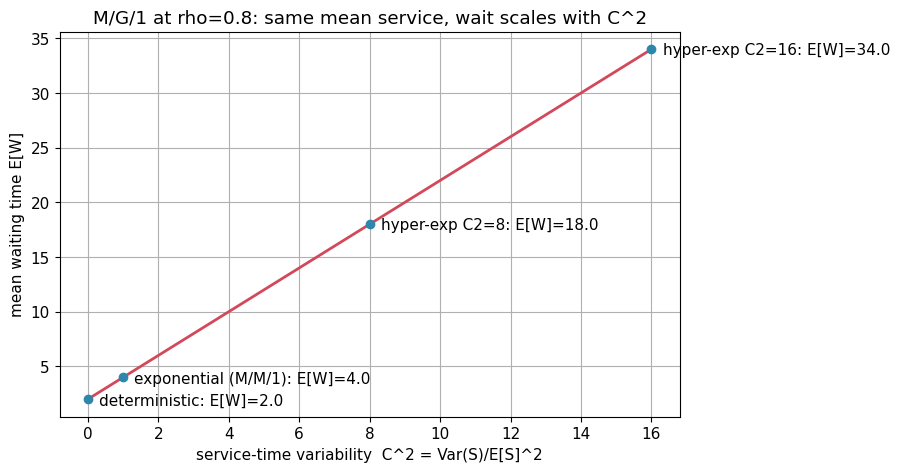

C^2=  0.0:  E[W]=  2.00   (0.50x the M/M/1 wait)

C^2=  1.0:  E[W]=  4.00   (1.00x the M/M/1 wait)

C^2=  8.0:  E[W]= 18.00   (4.50x the M/M/1 wait)

C^2= 16.0:  E[W]= 34.00   (8.50x the M/M/1 wait)

In [2]:
cv2_grid = np.linspace(0, 16, 33)
waits = [mean_wait(c) for c in cv2_grid]

fig, ax = plt.subplots()
ax.plot(cv2_grid, waits, color="#d1495b", lw=2)
labels = {0.0: "deterministic", 1.0: "exponential (M/M/1)", 8.0: "hyper-exp C2=8", 16.0: "hyper-exp C2=16"}
for cv2, name in labels.items():
    w = mean_wait(cv2)
    ax.scatter([cv2], [w], zorder=5, color="#2e86ab")
    ax.annotate(f"{name}: E[W]={w:.1f}", (cv2, w), textcoords="offset points", xytext=(8, -4))
ax.set_xlabel("service-time variability  C^2 = Var(S)/E[S]^2")
ax.set_ylabel("mean waiting time E[W]")
ax.set_title("M/G/1 at rho=0.8: same mean service, wait scales with C^2")
plt.show()

base = mean_wait(1.0)
for cv2 in [0.0, 1.0, 8.0, 16.0]:
    print(f"C^2={cv2:5.1f}:  E[W]={mean_wait(cv2):6.2f}   ({mean_wait(cv2)/base:.2f}x the M/M/1 wait)")


**The insight.** At the same mean and the same load, a deterministic server makes customers wait
**half** as long as an exponential one, while a heavy-tailed service (C²=16) makes them wait **8.5x
longer**. The averages are identical — only the *spread* differs.

## Why engineers should care

Real systems are full of variance sources that don't change the mean but wreck the tail:
- a few very large requests among many small ones (heavy-tailed sizes),
- retries, cold starts, GC/JIT pauses, cache misses,
- "bimodal" workloads (fast path vs slow path).

Levers that **reduce C²** — capping request sizes, separating slow jobs into their own queue,
smoothing batch sizes, warming caches — often cut latency more than buying a faster (lower-mean)
server. Size-aware scheduling (see the [SRPT tutorial](srpt_basics.ipynb)) is another: it reshapes
how variance translates into delay.

## Takeaways

- Latency depends on **both** the mean **and** the variance of service. `E[W] ∝ (1+C²)/2`.
- A deterministic service halves the wait vs exponential; a heavy-tailed one multiplies it.
- When latency is too high, ask *"what's my C²?"* before buying more/faster hardware.